# Lentils foreign-object segmentation with DynUNet — inference

Load a pipeline trained by [`01_train.ipynb`](01_train.ipynb), run it over the **180-frame test
split** with a `Predictor`, and report:

- **segmentation metrics** — foreground IoU / Dice / pixel accuracy — read straight off the
  pipeline's `SegMetrics` node (the node-metric idiom: the node accumulates during the pass, you read
  `compute()`), and
- **qualitative panels** — false-colour scene, foreground-probability heatmap, and prediction-vs-GT
  contours for a few object frames.

At inference the graph runs `Norm → DynUNet` (the losses are stage-gated off and the augmentation is
an identity passthrough); DynUNet tiles each full frame with Gaussian-blended overlaps, `tile_batch`
packing the tiles onto the batch axis (~16× faster, output-identical).

> **Prerequisites**
>
> 1. Install the plugin with the notebooks extra: `uv sync --extra notebooks` from the repo root,
>    plus `cuvis-ai-augment` (the trained graph contains its augmentation node).
> 2. From the repo root, launch with `uv run jupyter lab`.
> 3. Train + save a pipeline first (run `01_train.ipynb`). This notebook loads it from `PIPELINE_DIR`
>    (configuration cell; defaults to the train notebook's `outputs/lentils_unet_run/trained_models`).
>
> **Data**: reuses the per-frame NPZ the train notebook wrote to `outputs/npz_local`
> (`universe.csv` + `splits.json`); if absent it downloads + converts with
> `PublicDatasets.download_dataset` + `convert_split_manifest` (needs `cuvis-ai-dataloader[cu3s,coco]`
> + the Cuvis SDK). The test split is resolved from the splits.json.

In [1]:
# Colab bootstrap: no-op when running locally
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab Env")
    %pip install -q cuvis-ai "cuvis-ai-dataloader[cu3s,coco]>=0.5" "cuvis-ai-unet @ git+https://github.com/cubert-hyperspectral/cuvis-ai-unet.git" "cuvis-ai-augment @ git+https://github.com/cubert-hyperspectral/cuvis-ai-augment.git@v0.3.2"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: No GPU detected. Switch via Runtime > Change runtime type > GPU. "
            "DynUNet inference on CPU is slow."
        )

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import utils
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor
from cuvis_ai_core.utils.node_registry import NodeRegistry
from cuvis_ai_dataloader.data import MultiNpzDataModule
from cuvis_ai_dataloader.data.npz_converter import convert_split_manifest
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.execution import Context
from cuvis_ai_schemas.training import DataSplitConfig
from loguru import logger

In [3]:
# Big frames (~263 MB) + DataLoader workers can exhaust /dev/shm under the default sharing strategy;
# file_system avoids it (harmless here at num_workers=0, matches the training notebook).
torch.multiprocessing.set_sharing_strategy("file_system")

logger.remove()
logger.add(sys.stderr, level="INFO")

device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

2026-07-17 21:58:35.385 | INFO     | __main__:<module>:13 - Using device cuda


## Tutorial configuration

- **`PIPELINE_DIR`**: a train notebook's `trained_models` dir (holds the single `*.yaml` + its `.pt`).
  Defaults to the trainrun output; the manual path writes `lentils_unet_manual.*` in the same dir.
- **`TEST_LIMIT`**: 0 evaluates the full test split; N evaluates the first N frames.
- **`N_PANELS`**: how many object frames to render in section 4.
- **`SMOKE_LIMIT`**: only used if the NPZ isn't already on disk — frames/split to convert here (keep
  it equal to what `01_train.ipynb` used so the test split matches).

In [4]:
PIPELINE_DIR = Path("outputs/lentils_unet_run/trained_models")  # a train notebook's output dir
TEST_LIMIT = 0  # 0 = full 180-frame test split; N = first N frames
N_PANELS = 3  # object frames to render in section 4
SMOKE_LIMIT = (
    12  # frames/split if converting fresh here (match 01_train.ipynb; ignored if NPZ exists)
)

PIPE_YAML, PIPE_PT = utils.resolve_pipeline(PIPELINE_DIR)
print(f"Pipeline dir:  {PIPELINE_DIR}")
print(f"Pipeline YAML: {PIPE_YAML}")
print(f"Weights:       {PIPE_PT} ({PIPE_PT.stat().st_size / 1e6:.1f} MB)")
print(f"Test limit:    {TEST_LIMIT or 'full (180)'}")

Pipeline dir:  outputs/lentils_unet_run/trained_models
Pipeline YAML: outputs/lentils_unet_run/trained_models/lentils_unet_manual.yaml
Weights:       outputs/lentils_unet_run/trained_models/lentils_unet_manual.pt (32.6 MB)
Test limit:    full (180)


## 1 · Load the trained pipeline + data

Register the unet + augment plugins (so the saved node classes resolve), then
`CuvisPipeline.load_pipeline` rebuilds the graph and loads the weights. The NPZ (reused from the
train notebook, or downloaded + converted here) is served by `MultiNpzDataModule`; `setup("predict")`
prepares the predict split (a copy of `test`).

In [5]:
registry = NodeRegistry()
registry.register_plugin(str(utils.UNET_MANIFEST))
registry.register_plugin(str(utils.AUGMENT_MANIFEST))
pipeline = CuvisPipeline.load_pipeline(
    str(PIPE_YAML), weights_path=str(PIPE_PT), device=str(device), node_registry=registry
)
pipeline.torch_layers.eval()
print("Loaded:", pipeline.name, "| nodes:", [n.name for n in pipeline.nodes])

# Fetch + convert the dataset to per-frame NPZ (skipped when the artifacts already exist -- the
# train notebook writes them to the same outputs/npz_local).
LENTILS_DATASET_NAME = "industrial_fod_lentils"
NPZ_DIR = Path("outputs/npz_local")
SPLITS_JSON = NPZ_DIR / "splits.json"
UNIVERSE_CSV = NPZ_DIR / "universe.csv"
if not (SPLITS_JSON.is_file() and UNIVERSE_CSV.is_file()):
    dataset_dir = Path("/content/data") if IN_COLAB else Path("../../data")
    raw_dir = dataset_dir / "XMR_Industrial_Foreign_Object_Detection_Lentils"
    PublicDatasets.download_dataset(
        LENTILS_DATASET_NAME, download_path=str(dataset_dir), force=False
    )
    result = convert_split_manifest(
        raw_dir / "splits.csv",
        raw_dir,
        NPZ_DIR,
        universe_csv=UNIVERSE_CSV,
        splits_json=SPLITS_JSON,
        limit=SMOKE_LIMIT,  # 0 = convert all frames; must match what 01_train.ipynb used
    )
    SPLITS_JSON, UNIVERSE_CSV = result.splits_json, result.universe_csv

datamodule = MultiNpzDataModule(
    splits=DataSplitConfig(splits_path=str(SPLITS_JSON.resolve())),
    universe_csv=str(UNIVERSE_CSV),
    batch_size=1,
    num_workers=0,
)
datamodule.setup(stage="predict")  # Predictor evaluates the predict split (a copy of test)
print("Predict (= test) frames:", len(datamodule.predict_ds))

2026-07-17 21:58:35.398 | INFO     | cuvis_ai_core.utils.node_registry:register_plugins_installed:534 - Loaded preinstalled plugin 'unet' with 4 nodes


2026-07-17 21:58:35.398 | INFO     | cuvis_ai_core.utils.node_registry:register_plugin:380 - Registered plugin 'unet' from /mnt/data/anish/cuvis-ai-unet/plugins.yaml


2026-07-17 21:58:35.401 | INFO     | cuvis_ai_core.utils.node_registry:register_plugins_installed:534 - Loaded preinstalled plugin 'augment' with 1 nodes


2026-07-17 21:58:35.401 | INFO     | cuvis_ai_core.utils.node_registry:register_plugin:380 - Registered plugin 'augment' from /mnt/data/anish/cuvis-ai-unet/examples/lentils/augment.yaml


2026-07-17 21:58:35.562 | WARNING  | cuvis_ai.node.monitor:_resolve_log_dir:141 - Run directory 'lentils_unet' already exists. Using 'lentils_unet_v3' instead.


2026-07-17 21:58:35.563 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: outputs/lentils_unet_run/tensorboard/lentils_unet_v3


2026-07-17 21:58:35.563 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=outputs/lentils_unet_run/tensorboard


/mnt/data/anish/cuvis-ai/.venv/lib/python3.11/site-packages/cuvis_ai_core/pipeline/factory.py:238: MissingNodeMetadataWarning: Node class cuvis_ai_augment.node.compose.AugmentationCompose is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  pipeline._assign_counter_and_add_node(node)


Loaded: lentils_unet | nodes: ['DataSource', 'Norm', 'Augment', 'DynUNet', 'DiceLoss', 'CrossEntropyLoss', 'SegMetrics', 'TensorBoardMonitorNode']
Predict (= test) frames: 180


### Pipeline graph

Inline view of the restored graph. A `CuvisPipeline` renders itself in Jupyter as an SVG built from
Graphviz DOT (needs the system `dot` binary; it falls back to a Mermaid source block otherwise).

In [6]:
pipeline

lentils_unet:
CU3SDataNode()
ZScoreNormalizer()
AugmentationCompose()
DynUNet(
  (net): DynUNetBackbone(
    (encoder): ModuleList(
      (0): DoubleConvBlock(
        (unit1): ConvUnit(
          (block): Sequential(
            (0): Conv2d(61, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
            (2): LeakyReLU(negative_slope=0.01, inplace=True)
          )
        )
        (unit2): ConvUnit(
          (block): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          )
        )
        (proj): Conv2d(61, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (post_norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (post_act): LeakyReLU(negative_slope=0.01, inplace=True)
      )
      (1): DoubleConvBlock(
        (unit1): ConvUnit(
          (block): Sequential(
            (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
            (2): LeakyReLU(negative_slope=0.01, inplace=True)
          )
        )
        (unit2): ConvUnit(
          (block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          )
        )
        (proj): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (post_norm): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (post_act): LeakyReLU(negative_slope=0.01, inplace=True)
      )
      (2): DoubleConvBlock(
        (unit1): ConvUnit(
          (block): Sequential(
            (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
            (2): LeakyReLU(negative_slope=0.01, inplace=True)
          )
        )
        (unit2): ConvUnit(
          (block): Sequential(
            (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          )
        )
        (proj): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (post_norm): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (post_act): LeakyReLU(negative_slope=0.01, inplace=True)
      )
      (3): DoubleConvBlock(
        (unit1): ConvUnit(
          (block): Sequential(
            (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
            (2): LeakyReLU(negative_slope=0.01, inplace=True)
          )
        )
        (unit2): ConvUnit(
          (block): Sequential(
            (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          )
        )
        (proj): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (post_norm): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (post_act): LeakyReLU(negative_slope=0.01, inplace=True)
      )
      (4): DoubleConvBlock(
        (unit1): ConvUnit(
          (block): Sequential(
            (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=True, tr

## 2 · Run inference on the test split

`Predictor` runs the loaded pipeline over the split — no hand-rolled forward loop. With
`stage=ExecutionStage.TEST` the pipeline's `SegMetrics` node fires and accumulates per-frame
foreground IoU / Dice + pixel accuracy across this single pass. `collect_outputs=False` keeps memory
flat — the metrics live on the node and are read in section 3.

In [7]:
Predictor(pipeline, datamodule).predict(
    stage=ExecutionStage.TEST,
    collect_outputs=False,
    max_batches=(TEST_LIMIT or None),
)
print("Test pass complete.")

Predict [lentils_unet]:   0%|          | 0/180 [00:00<?, ?batch/s]

Test pass complete.


## 3 · Segmentation metrics

Read straight off the `SegMetrics` node, which accumulated during the pass above: foreground IoU /
Dice are averaged over object frames (frames with no foreground are skipped, matching the champion
evaluation), pixel accuracy is over all evaluated pixels. A 1-epoch tutorial model sits far below the
champion reference — the comparison line shows the gap.

In [8]:
seg = {n.name: n for n in pipeline.nodes}["SegMetrics"]
m = seg.compute()
champ = utils.CHAMPION["2d_128"]
print(f"fg_iou    = {m['fg_iou']:.4f}   (champion {champ['fg_iou']:.4f})")
print(f"fg_dice   = {m['fg_dice']:.4f}   (champion {champ['fg_dice']:.4f})")
print(f"pixel_acc = {m['pixel_acc']:.4f}")

fg_iou    = 0.8260   (champion 0.7905)
fg_dice   = 0.9016   (champion 0.8787)
pixel_acc = 0.9997


## 4 · Qualitative panels

Pick a few test frames that actually contain a foreign object (a cheap mask-only scan — normal frames
have nothing to show), then spell out the two-node inference path: z-score the frame, run DynUNet's
tiled full-frame forward, softmax the logits into a foreground-probability map, and argmax into a
predicted mask. Cubes are reloaded for a true false-colour view (red = GT contour, cyan = prediction).

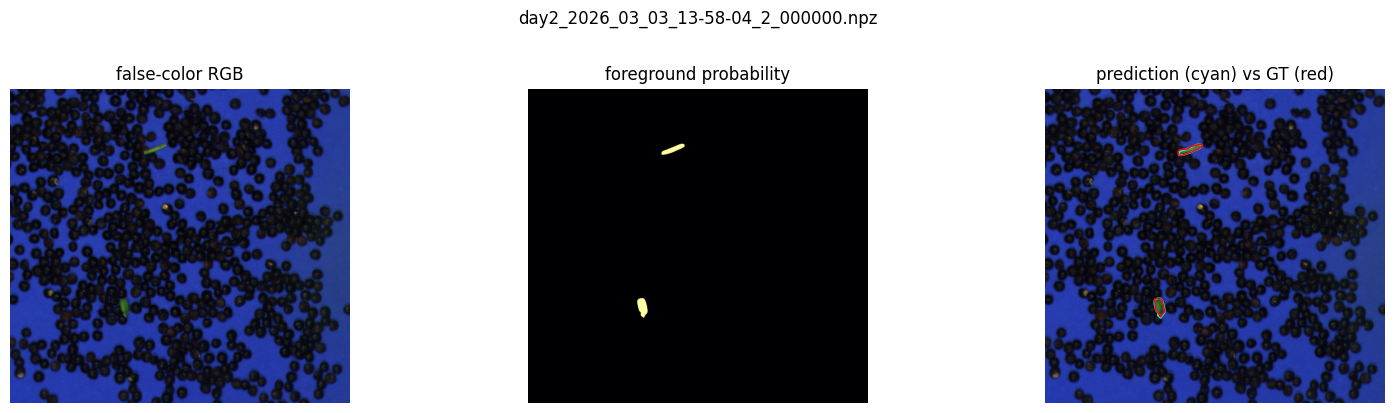

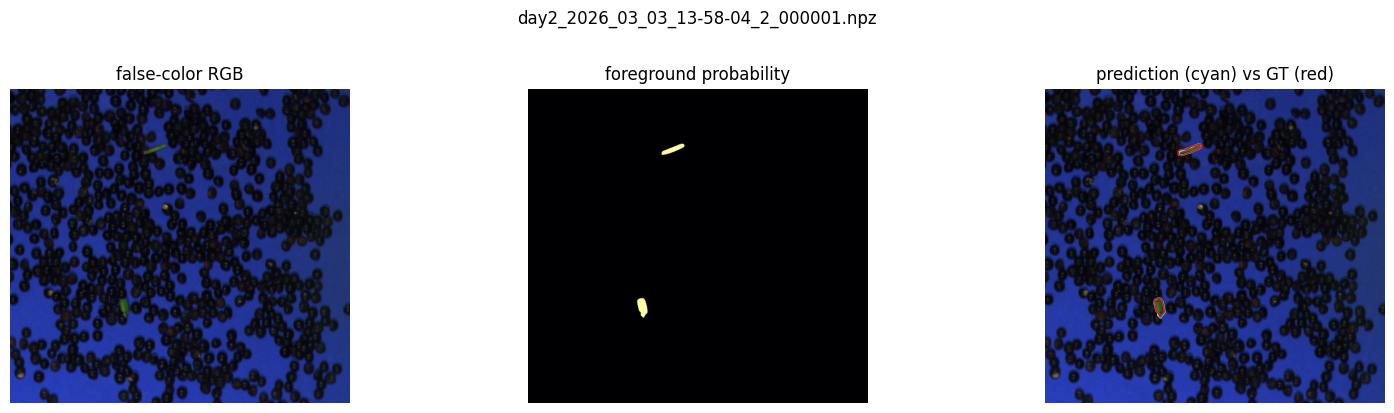

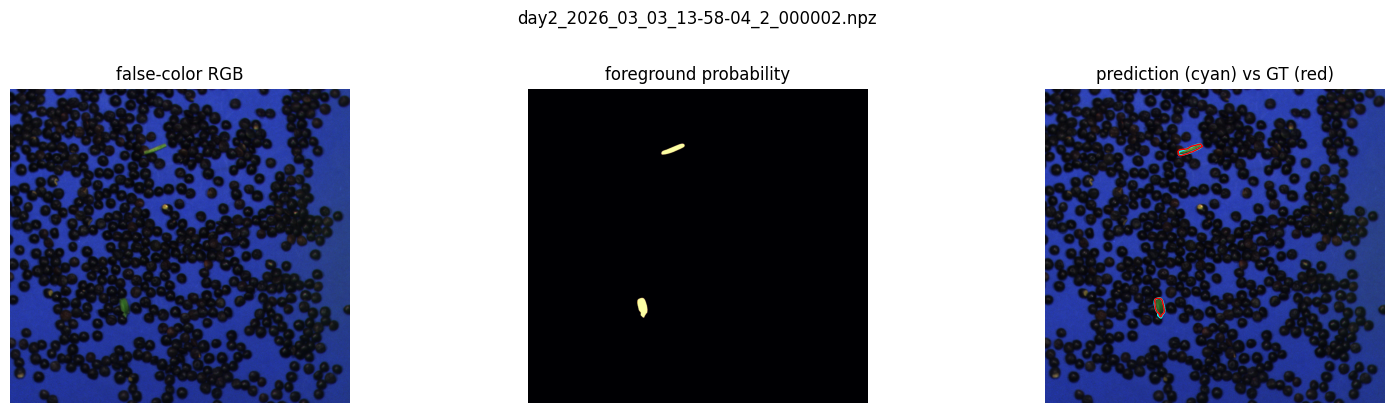

In [9]:
nodes = {n.name: n for n in pipeline.nodes}
norm, net = nodes["Norm"], nodes["DynUNet"]
dev = next(net.parameters()).device
rows = getattr(datamodule.predict_ds, "rows", [])

# object frames only -- a mask-only load never touches the ~263 MB cube
object_paths = []
for r in rows:
    with np.load(r["materialized_path"]) as z:
        if "mask" in z.files and bool(np.asarray(z["mask"]).any()):
            object_paths.append(r["materialized_path"])
    if len(object_paths) >= N_PANELS:
        break

infer_ctx = Context(stage=ExecutionStage.INFERENCE, batch_idx=0, global_step=0)
for p in object_paths:
    frame = utils.load_lentils_frame(p)
    cube = torch.from_numpy(frame["cube"]).unsqueeze(0).to(dev)
    with torch.no_grad():
        normed = norm.forward(data=cube)["normalized"]
        logits = net.forward(normed, context=infer_ctx)["logits"][0]  # [H, W, 2]
        fg_prob = torch.softmax(logits.float(), dim=-1)[..., 1].cpu().numpy()
        pred = (logits.argmax(-1) >= 1).cpu().numpy()
    utils.render_segmentation_panel(
        frame["cube"],
        fg_prob,
        pred,
        wavelengths=frame["wavelengths"],
        gt_mask=frame["mask"],
        title=Path(p).name,
    )
    plt.show()

if not object_paths:
    print("(no object frames in the predict split)")

## Takeaways

- Numbers come from *your* trained pipeline: a 1-epoch smoke will look weak. For a real result, set
  `MAX_EPOCHS = 20` in `01_train.ipynb` and rerun, or launch the champion CLI in that notebook's
  closing section.
- `SegMetrics` covers the pixel task. The `evaluate.py` CLI additionally reports **image-level AUROC**
  (frame-has-object detection, champion ≈ 0.998) via direct tiled inference — run it for the full
  champion comparison.
- To trade a little accuracy for ~3× faster evaluation, rebuild DynUNet with `tile_overlap=0`
  (`tile_gaussian=False`); `examples/lentils/profile_pipeline.py` sweeps the tiling knobs.